In [5]:
import numpy as np
import matplotlib.pyplot as plt
import thermodynamics as thermo
import ODESolve_slow as ODE
from constants import me, mpl

In [7]:
def sth(T):
    sth=((2*np.pi**2*2*T**3)/45)+thermo.s(T,me,2)+thermo.s(T,me,2)
    return sth
print (sth(10))

2412.1348418210628


In [9]:
def dsthdT(T):
    dsthdT=(6*np.pi**2*2*T**2)/45+thermo.dsdT(T,me,2)+thermo.dsdT(T,me,2)
    return dsthdT

In [11]:
def ptot(T,a):
    ptot=(np.pi**2*2*T**4)/30+thermo.p(T,me,2)+thermo.p(T,me,2)+thermo.p(1/a,0,6)
    return ptot

In [13]:
def f(a,y,p):
   
    T,t=y
    der = np.zeros(2)
   
    der[0] = -(3*a**2*sth(T))/(a**3*dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ptot(T,a))/(3*(mpl)**2))**(1/2)

    
    return der

a0=0.1
y0=np.array([10,0])
dx0=0.001
p=None

N_step = 1000
dN = 2
x_final = 100

print(f(a0,y0,p)) 
a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

[-9.99879777e+01  4.46148637e-19]
True


[10.          9.66033387  9.03447701  8.33334198  7.60955429  6.88903138
  6.18730111  5.51437633  4.87685329  4.27901528  3.72349229  3.21169159
  2.74409628  2.32048142  1.94007514  1.60168128  1.30377415  1.04457264
  0.82209804  0.63421532  0.47864574  0.36393777  0.28600374  0.22943529
  0.18518168  0.1455234   0.11926441  0.1013209   0.08682669  0.07452108
  0.06375974  0.05376236  0.04285391  0.03514633  0.02815701  0.02070287
  0.01400935]


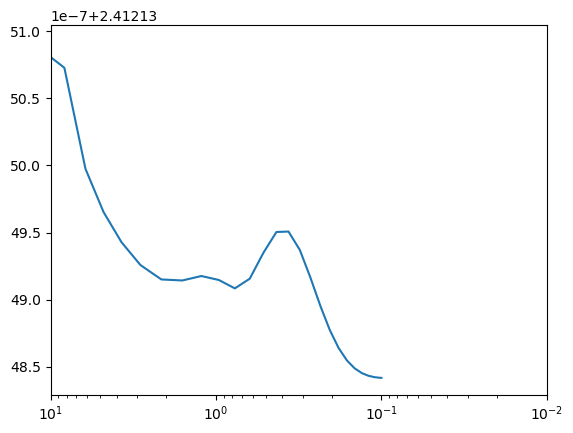

In [14]:
plt.figure()
T=y[:,0]
z=np.zeros(len(T))
for i in range(len(T)):
    z[i]=sth(T[i])*a[i]**3
plt.semilogx(a,z)
plt.xlim(10,0.01)
print(T)
   


(0.0, 20.0)

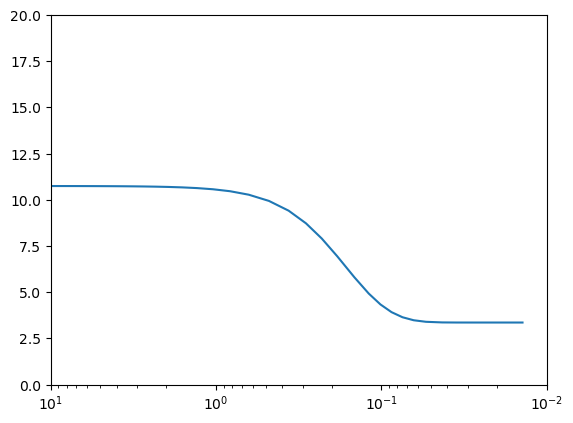

In [17]:
plt.figure()
T=y[:,0]
g=np.zeros(len(T))
for i in range(len(T)):
    g[i]=ptot(T[i],a[i])/(np.pi**2*T[i]**4/30)
plt.semilogx(T,g)
plt.xlim(10,.01)
plt.ylim(0,20)
